# Demonstration
This notebook is designed to give a full streamlined presentation of my analysis on NBA player data and trying to find the relationship between a player play style (archetype) and how successful a player is (measured by PER and Win Shares). The code for all functions used in this notebook can be found in the functions.py file. Furthermore, it's just been taken from previous notebooks and used here.

In [1]:
# Imports
import pandas as pd
import numpy as np
import shap
from functions import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
print('Imports Done!')

Imports Done!


### Pull in the data

The first step is to pull in the data I will be using. The data set I will be using is the 2024-2025 NBA player data. It is a combination of their per game box score numbers and their advanced stats calculated across the season. All data is publicly available and pulled from [basketball-reference.org](basketball-reference.org). The pull data function used below pulls all the data from the website, and merges it into one data frame we can use.

In [9]:
df = pull_data()

df

,index,Rk_x,Player,Age,Team,Pos,G,GS,MP_x,FG,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,...,8.6,34.8,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9
1,1,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,...,11.2,35.2,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6
2,2,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,11.2,...,12.8,29.5,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8
3,4,4.0,Luka Dončić,25.0,DAL,PG,22.0,22.0,35.7,9.8,...,12.4,33.1,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8
4,5,4.0,Luka Dončić,25.0,LAL,PG,28.0,28.0,35.1,8.8,...,13.5,34.5,2.0,1.4,3.4,0.164,5.5,1.1,6.5,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,730,565.0,Riley Minix,24.0,SAS,SF,1.0,0.0,7.0,0.0,...,0.0,6.1,0.0,0.0,0.0,-0.114,-8.5,-3.3,-11.8,0.0
650,731,566.0,Jahlil Okafor,29.0,IND,C,1.0,0.0,3.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.196,2.5,4.9,7.5,0.0
651,732,567.0,Zyon Pullin,23.0,MEM,SG,3.0,0.0,1.0,0.0,...,0.0,13.4,0.0,0.0,0.0,-0.304,-15.0,-7.7,-22.7,0.0
652,733,568.0,Isaiah Stevens,24.0,MIA,PG,3.0,0.0,2.0,0.0,...,0.0,14.8,0.0,0.0,0.0,-0.196,-19.5,7.7,-11.8,0.0


Now that all the data is pulled, the next step is to process it and prepare it for machine learning models

### Preprocessing

In this analysis we really wanted to level the playing field for all the players. Naturally players who play more will have higher box score stats than those that play less. So we divided the box score stats that we will be using in future steps by each players minutes played to calculate their per minute numbers. This helps to level the playing field between players who play a lot, and those who don't. We also subset to players who played at least 5 minutes per game. This protects against a per minute stat being inflated due to a player having played a super minimal number of minutes across the season. Finally, since the data set was already pretty full (not many NA's) it was decided to drop all rows with NA's as well.

The preprocess() function does all of this and you can see the final result. The data set is still fairly large (551 players) even with dropping all NA's and subsetting to at least 5 minutes played.

In [10]:
df_preprocessed = preprocess(df)

df_preprocessed

,Player,Team,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,BLK_per_min,PF_per_min,3PAr,USG%,FTr,TOV%,PER,WS
0,Shai Gilgeous-Alexander,OKC,0.470760,0.166667,0.257310,0.956140,0.187135,0.026316,0.119883,0.049708,0.029240,0.064327,0.263,34.8,0.404,8.6,30.7,16.7
1,Giannis Antetokounmpo,MIL,0.546784,0.026316,0.309942,0.888889,0.190058,0.064327,0.283626,0.026316,0.035088,0.067251,0.048,35.2,0.536,11.2,30.5,11.5
2,Nikola Jokić,DEN,0.403270,0.128065,0.174387,0.806540,0.277929,0.079019,0.269755,0.049046,0.016349,0.062670,0.243,29.5,0.331,12.8,32.0,16.4
3,Luka Dončić,DAL,0.322129,0.268908,0.184874,0.787115,0.218487,0.019608,0.212885,0.056022,0.011204,0.072829,0.455,33.1,0.313,12.4,24.2,2.5
4,Luka Dončić,LAL,0.296296,0.273504,0.253561,0.803419,0.213675,0.025641,0.205128,0.045584,0.011396,0.068376,0.481,34.5,0.445,13.5,23.9,3.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Spencer Jones,DEN,0.142857,0.142857,0.031746,0.206349,0.047619,0.063492,0.079365,0.047619,0.047619,0.142857,0.500,13.7,0.088,12.4,4.5,-0.1
627,Xavier Tillman Sr.,BOS,0.085714,0.142857,0.014286,0.142857,0.028571,0.042857,0.142857,0.042857,0.028571,0.071429,0.604,13.1,0.075,20.4,2.4,-0.3
628,Luke Travers,CLE,0.123288,0.109589,0.027397,0.136986,0.095890,0.095890,0.136986,0.013699,0.013699,0.068493,0.450,13.9,0.100,27.7,1.9,-0.1
630,Justin Minaya,POR,0.113208,0.094340,0.018868,0.169811,0.075472,0.056604,0.056604,0.056604,0.018868,0.113208,0.476,11.1,0.095,18.6,5.0,0.0


Now that the data has been cleaned and processed, it is ready for the next step in the analysis: clustering.

### Clustering

Here is where we used our first machine learning technique: kMeans clustering. The goal of this clustering was to cluster players based off of their play style while in the court. There were two clustering models used: a 3 clusters model, and a 9 clusters model. This was done because after looking at the elbow plot and a plot of the sillhouette scores it was shown that 3 clusters was the most efficient, but 9 clusters allowed a more granular insight into specific player play styles. The variables passed into the kMeans models are: 2PA_per_min 3PA_per_min, FTA_per_min, PTS_per_min, AST_per_min, ORB_per_min, DRB_per_min, STL_per_min, BLK_per_min, 3PAr, USG%, and FTr.

After clustering the data and analyzing the clusters each cluster was assigned a specific label. The 3 clusters model split players into these three groups: High Usage Offensive Players, Balanced Role Players, and Rebounding Bigs. And, the 9 clusters model split players into the following 9 groups: Interior Scoring Stars, Primary Offensive Engines, Secondary Scoring Options, High Volume Three Point Specialists, Low Usage Floor Spacers, Stretch Bigs, Traditional Interior Bigs, Defensive Guards, and Secondary Playmakers. The add_clustering() function below makes those clusters and assigns them to each player. You can see that a new columns are added which include both the cluster number and the cluster label assigned to each player.

In [4]:
df_clusters = add_clustering(df_preprocessed)

df_clusters

,Player,Team,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,...,3PAr,USG%,FTr,TOV%,PER,WS,cluster_3,cluster_9,cluster_3_label,cluster_9_label
0,Shai Gilgeous-Alexander,OKC,0.470760,0.166667,0.257310,0.956140,0.187135,0.026316,0.119883,0.049708,...,0.263,34.8,0.404,8.6,30.7,16.7,0,0,High Volume Offensive Stars,Interior Scoring Stars
1,Giannis Antetokounmpo,MIL,0.546784,0.026316,0.309942,0.888889,0.190058,0.064327,0.283626,0.026316,...,0.048,35.2,0.536,11.2,30.5,11.5,0,0,High Volume Offensive Stars,Interior Scoring Stars
2,Nikola Jokić,DEN,0.403270,0.128065,0.174387,0.806540,0.277929,0.079019,0.269755,0.049046,...,0.243,29.5,0.331,12.8,32.0,16.4,0,0,High Volume Offensive Stars,Interior Scoring Stars
3,Luka Dončić,DAL,0.322129,0.268908,0.184874,0.787115,0.218487,0.019608,0.212885,0.056022,...,0.455,33.1,0.313,12.4,24.2,2.5,0,3,High Volume Offensive Stars,Primary Offensive Engines
4,Luka Dončić,LAL,0.296296,0.273504,0.253561,0.803419,0.213675,0.025641,0.205128,0.045584,...,0.481,34.5,0.445,13.5,23.9,3.4,0,3,High Volume Offensive Stars,Primary Offensive Engines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,Spencer Jones,DEN,0.142857,0.142857,0.031746,0.206349,0.047619,0.063492,0.079365,0.047619,...,0.500,13.7,0.088,12.4,4.5,-0.1,1,4,Balanced Role Players,Low Usage Floor Spacers
627,Xavier Tillman Sr.,BOS,0.085714,0.142857,0.014286,0.142857,0.028571,0.042857,0.142857,0.042857,...,0.604,13.1,0.075,20.4,2.4,-0.3,1,4,Balanced Role Players,Low Usage Floor Spacers
628,Luke Travers,CLE,0.123288,0.109589,0.027397,0.136986,0.095890,0.095890,0.136986,0.013699,...,0.450,13.9,0.100,27.7,1.9,-0.1,1,4,Balanced Role Players,Low Usage Floor Spacers
630,Justin Minaya,POR,0.113208,0.094340,0.018868,0.169811,0.075472,0.056604,0.056604,0.056604,...,0.476,11.1,0.095,18.6,5.0,0.0,1,4,Balanced Role Players,Low Usage Floor Spacers


While the 3 cluster clustering was interesting, the results weren't granular enough for the analysis we wanted to perform. The 9 clusters model did a much better job at giving insight into a players actual play style, not just if they are a teams main option or not. 

### Make Graphs

Below are some graphs to help visualize the clustered groups. The make_clustering_graphs() function makes the PCA graphs of the players and colors by the different clusters for each player. Additionally it creates a scatter plot of Win Shares and PER for each of the 9 clusters made by the model.

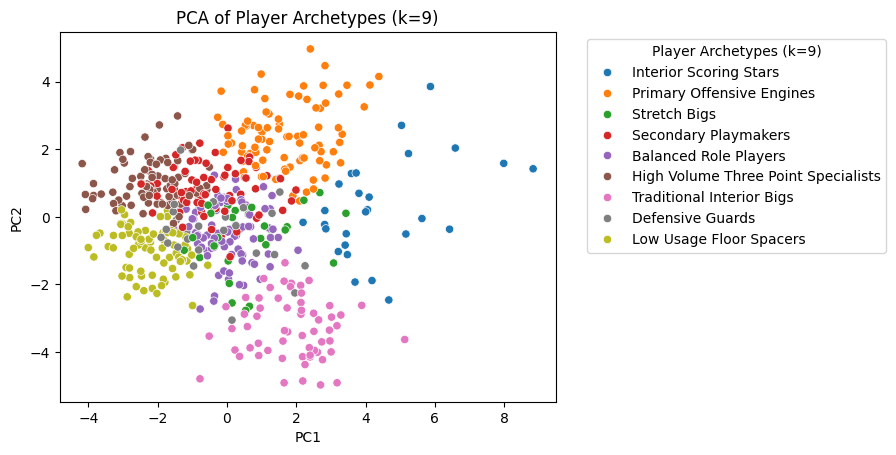

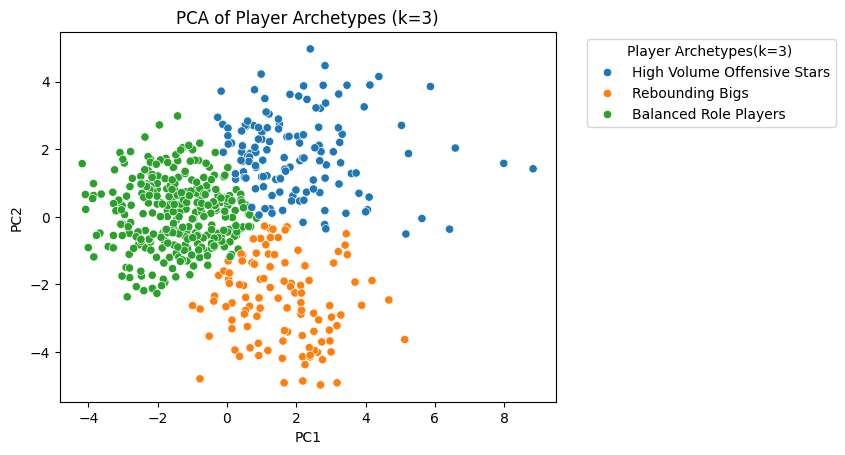

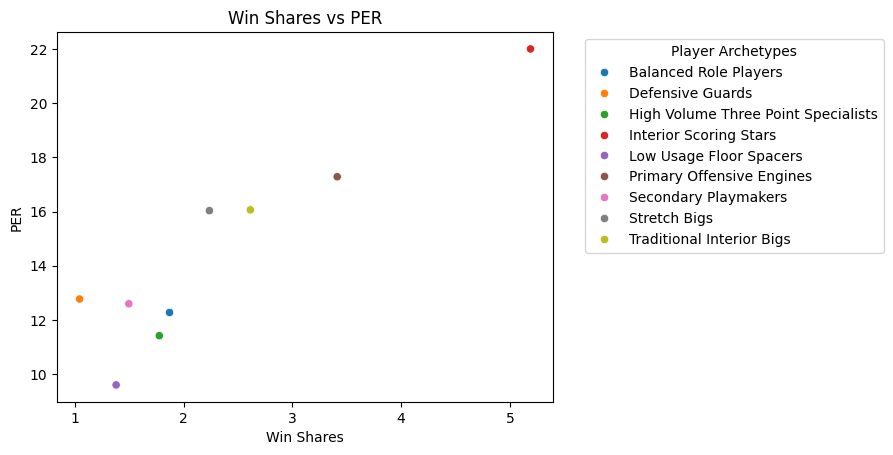

In [5]:
make_clustering_graphs(df_clusters)

The 3 clustering model has a much more defined decision boundaries when the dimensionality is reduced. The 9 clustering model is much more mixed with more overlap between groups. In spite of that mix, the groups still have their own general spacing and place in the plot, really still making 9 distinct different groups in the plot. Finally we can see a relationship between PER and Win Shres, with more efficient players being contributing to more wins. You can also see that the "Interior Scoring Stars" are far and away the most efficient and winning group.

### Make Predictions

The final step in the process is to make predictions with the clustering results to predict Win Shares and PER. A linear regression model and a random forest regression model was fit to predict both Win Shares and PER. The predictor variables passed into all models were the same: 2PA_per_min, FTA_per_min, USG%, PF_per_min, 3PA_per_min, TOV%, 3PAr, and the cluster label from the 9 clusters model. The split_and_prep functions splits the data into an 80/20 train/test split, it also scales all the data based off of the training data set. It outputs both the scaled data and the original data.

The linear_regression() fuction fits all of the linear regression models and then prints out the train and test RMSE for all of the linear models fit, and the rf_regression() fits all of the random forest models and prints out the train and test RMSE for all of the random forest models. The hyper parameters for the two were found using a Grid Search Cross Validation function. It takes a while to run, so we just took the resulting best hyper parameters and they are included in the rf_regression() function. The hyper parameters for the two random forest models are as follows:

PER: max_depth=7, min_samples_leaf=1, min_samples_split=5, n_estimators=200

Win Shares: max_depth=5, min_samples_leaf=5, min_samples_split=20, n_estimators=100

In order to fairly predict on every player in the data set, we ran a cross validation prediction method which would retrain a model and give predictions on the out of sample players. So every player was given an out of sample prediction. The resulting residuals (actual - predicted) from that prediction was then tacked onto the data frame at the end. I included a look at each player and their resulting residuals from the models.

In [6]:
X_train_original, X_train, X_test_original, X_test, y_train, y_test = split_and_prep(df_clusters)

linear_regression(X_train, y_train, X_test, y_test, df_clusters)

rf_regression(X_train, y_train, X_test, y_test, df_clusters)

df_clusters[['Player', 'lin_resid_per', 'lin_resid_ws', 'rf_resid_per', 'rf_resid_ws']]

Linear PER Train RMSE: 2.7202605142880953, Linear PER Test RMSE: 3.448331424684772, Linear WS Train RMSE: 2.040894453902904, Linear WS Test RMSE:2.6291767129141417
RF PER Train RMSE: 1.8735792467508865, RF PER Test RMSE: 3.4789460783981028, RF WS Train RMSE: 1.7877028496153402, RF WS Test RMSE:2.6084469399871995


,Player,lin_resid_per,lin_resid_ws,rf_resid_per,rf_resid_ws
0,Shai Gilgeous-Alexander,8.349979,15.454499,11.734181,15.436341
1,Giannis Antetokounmpo,4.833087,10.156855,10.413221,8.508619
2,Nikola Jokić,13.081603,14.927933,14.257936,15.356261
3,Luka Dončić,6.566643,1.992351,8.333697,1.685845
4,Luka Dončić,4.901695,3.261689,6.862892,2.671287
...,...,...,...,...,...
620,Spencer Jones,-6.040944,-0.543348,-7.853383,-1.950728
627,Xavier Tillman Sr.,-5.542793,-1.080002,-7.875586,-2.162564
628,Luke Travers,-5.736003,-0.526401,-8.823328,-1.613272
630,Justin Minaya,-3.702631,-0.411750,-3.872278,-1.523814


What's interesting is the linear model had a better test RMSE on predicting PER than the random forest model even after running a grid search cross validtaion to find the ideal hyper parameters. Even on Win Shares the random forest model was only barely better at predicting Win Shares than the linear model. 

### Find Under and Over Performers

Finally the next step was to look at the residuals and use them to classify players as under or over performers. In order to classify a player as an under or over performer we looked at the absolute values of the residual. If that absolute value was larger than the perspective models RMSE then the player was classified as an under performer (if the residual was negative) or an over performer (if the residual was positive). Players where the absolute value of the residual wasn't larger than the RMSE of the respective model were just classified as an "As Expected" performer. Finally since the linear model was slightly better than the Random Forest for PER the linear model residuals were analyzed for PER and the Random Forest residuals were analyzed for the Win Shares performance. The find_performance() function below does that and outputs a performance data frame with each player.

In [7]:
df_performance = find_performance(df_clusters)

df_performance

,Player,Team,cluster_9_label,perf_label_per,perf_label_ws
0,Shai Gilgeous-Alexander,OKC,Interior Scoring Stars,Overperformer,Overperformer
1,Giannis Antetokounmpo,MIL,Interior Scoring Stars,Overperformer,Overperformer
2,Nikola Jokić,DEN,Interior Scoring Stars,Overperformer,Overperformer
3,Luka Dončić,DAL,Primary Offensive Engines,Overperformer,As Expected
4,Luka Dončić,LAL,Primary Offensive Engines,Overperformer,Overperformer
...,...,...,...,...,...
620,Spencer Jones,DEN,Low Usage Floor Spacers,Underperformer,As Expected
627,Xavier Tillman Sr.,BOS,Low Usage Floor Spacers,Underperformer,As Expected
628,Luke Travers,CLE,Low Usage Floor Spacers,Underperformer,As Expected
630,Justin Minaya,POR,Low Usage Floor Spacers,Underperformer,As Expected


An extremely interesting insight that can be seen here is that Luka Doncic on the Mavericks for the 2024-2025 season was actually only performing "As Expected" with respect to Win Shares.

### Find What's Important

Finally to find what is important for both PER and Win Shares we analyzed the SHAP values from the Random Forest Model. Below are the beeswarm plots of the SHAP values for each feature.

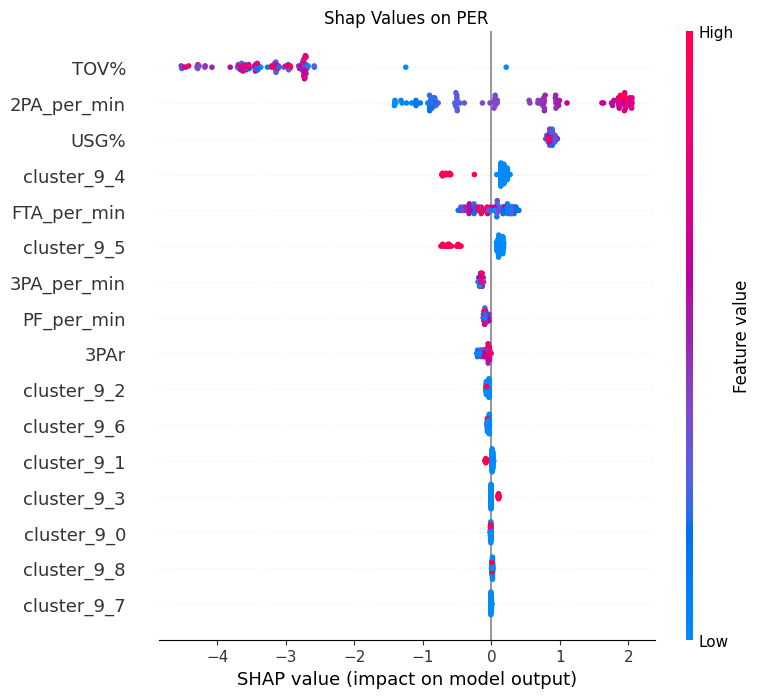

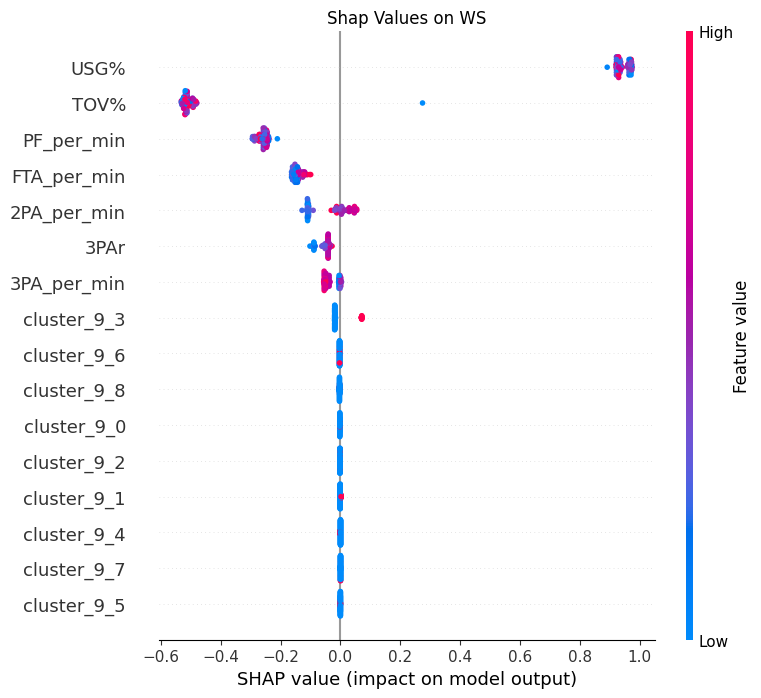

In [8]:
make_beeswarms(X_train, y_train, X_test, y_test, X_test_original)

Interestingly the players play style is not impactful at all when it comes to predicting Win Shares for players, while it was a bit more impactful for PER. Furthermore you can see that more efficient players are players with higher 2 point attempts, as you can see players with high 2 point attempts got an increase in their predicted PER. For both Win Shares and PER Turnover rate and usage rate were also highly impactful in trying to understand a players impact and efficiency on the court. 